# 3 Apr 2026
- basic notebook that samples IPTA MDC1 in linspharm basis using discovery -- new specspat formalism

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from glgp_paramorf import makeglobalgp_fourier_paramorf
from glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac

import matplotlib.patches as mpatches

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

## broadband analysis

In [23]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 6 # freq components
lmx = 6
nsi=1

psrpos = np.array([p.pos for p in psrs])

lsphorf = dac.get_linspharm_orf(psrpos, lmax=lmx)

glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
                                    [[functools.partial(lsphorf, c00=np.sqrt(4*np.pi))]],
                                    components=comps, T=T, name='gw', nbasis=[[(lmx+1)**2-1]])


# m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True)]) for psr in psrs],
#                        commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
#                        globalgp = glgp_mdc)

m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makenoise_measurement_simple(psr),
                                             ds.makegp_timing(psr, svd=True),
                                             ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
                                             globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

In [24]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 6 # freq components
lmx = 6
nsi=1

psrpos = np.array([p.pos for p in psrs])

lsphorf = dac.get_linspharm_orf(psrpos, lmax=lmx)

glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
                                    [[functools.partial(lsphorf, c00=np.sqrt(4*np.pi))]],
                                    components=comps, T=T, name='gw', nbasis=[[(lmx+1)**2-1]])

m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr),
                                             ds.makegp_timing(psr, svd=True),
                                             ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
                                             globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

In [25]:
mdc_jlogl.params

['J0030+0451_efac',
 'J0030+0451_log10_t2equad',
 'J0030+0451_rednoise_gamma',
 'J0030+0451_rednoise_log10_A',
 'J0218+4232_efac',
 'J0218+4232_log10_t2equad',
 'J0218+4232_rednoise_gamma',
 'J0218+4232_rednoise_log10_A',
 'J0437-4715_efac',
 'J0437-4715_log10_t2equad',
 'J0437-4715_rednoise_gamma',
 'J0437-4715_rednoise_log10_A',
 'J0613-0200_efac',
 'J0613-0200_log10_t2equad',
 'J0613-0200_rednoise_gamma',
 'J0613-0200_rednoise_log10_A',
 'J0621+1002_efac',
 'J0621+1002_log10_t2equad',
 'J0621+1002_rednoise_gamma',
 'J0621+1002_rednoise_log10_A',
 'J0711-6830_efac',
 'J0711-6830_log10_t2equad',
 'J0711-6830_rednoise_gamma',
 'J0711-6830_rednoise_log10_A',
 'J0751+1807_efac',
 'J0751+1807_log10_t2equad',
 'J0751+1807_rednoise_gamma',
 'J0751+1807_rednoise_log10_A',
 'J0900-3144_efac',
 'J0900-3144_log10_t2equad',
 'J0900-3144_rednoise_gamma',
 'J0900-3144_rednoise_log10_A',
 'J1012+5307_efac',
 'J1012+5307_log10_t2equad',
 'J1012+5307_rednoise_gamma',
 'J1012+5307_rednoise_log10_A',
 

In [12]:
mdcpars = {f'{p.name}_rednoise_gamma':2.0 for p in psrs}
mdcpars.update({f'{p.name}_rednoise_log10_A':-14.0 for p in psrs})
mdcpars.update({f'{p.name}_log10_t2equad':-14.0 for p in psrs})
mdcpars.update({f'{p.name}_efac':1.0 for p in psrs})
mdcpars['gw_log10_A'] = -15.0
mdcpars['gw_gamma'] = 4.33
mdcpars[f'gw_clm({(lmx+1)**2-1})'] = np.zeros((lmx+1)**2-1)
#mdcpars[f'gw_clm({(lmx+1)**2-1})'] = badclms

m_mdc.logL(mdcpars)

Array(24757.73772531, dtype=float64)

In [18]:
t1 = time.time()
for h in range(100):
    mdc_jlogl(mdcpars)

print(f'Time for 1 jitted logL evaluations: {(time.time()-t1)/100:.2f} seconds')

Time for 1 jitted logL evaluations: 0.03 seconds


In [8]:
# LSS mdc has no red noise, efac=1, no equad so set to -16
psrs = mdcpsrs

def model():
    gammas = numpyro.sample("gammas", dist.Uniform(0, 1).expand([len(psrs)]))
    log10_As = numpyro.sample("log10_As", dist.Uniform(-20, -19).expand([len(psrs)]))
    clmdraws = numpyro.sample(f"gw_clm({(lmx+1)**2-1})", dist.Uniform(-5, 5).expand([(lmx+1)**2-1]))
    gwgam = numpyro.sample('gw_gamma', dist.Uniform(0, 7))
    gwl10A = numpyro.sample('gw_log10_A', dist.Uniform(-20, -11))

    params = {f'{psr.name}_rednoise_gamma': gammas[ii] for ii, psr in enumerate(psrs)}
    params.update({f'{psr.name}_rednoise_log10_A': log10_As[ii] for ii, psr in enumerate(psrs)})
    params.update({f'{p.name}_log10_t2equad':-16.0 for p in psrs})
    params.update({f'{p.name}_efac':1.0 for p in psrs})
    params[f"gw_clm({(lmx+1)**2-1})"] = clmdraws
    params['gw_gamma'] = gwgam
    params['gw_log10_A'] = gwl10A
    numpyro.deterministic('params', params)
    numpyro.factor('logl', mdc_jlogl(params))


mykernel = infer.NUTS(model, max_tree_depth=5)
mcmc = infer.MCMC(mykernel, num_warmup=1000, num_samples=1000)


In [9]:
mcmc.run(jax.random.key(100))

sample: 100%|██████████| 2000/2000 [15:49<00:00,  2.11it/s, 15 steps of size 3.75e-01. acc. prob=0.85]


In [10]:
samples = mcmc.get_samples()
mcmc.print_summary()


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
   gammas[0]      0.50      0.29      0.51      0.06      0.97   2292.02      1.00
   gammas[1]      0.51      0.29      0.50      0.10      1.00   2058.14      1.00
   gammas[2]      0.50      0.29      0.49      0.07      0.95   1802.55      1.00
   gammas[3]      0.50      0.27      0.50      0.13      1.00   1731.36      1.00
   gammas[4]      0.50      0.28      0.50      0.04      0.92   1995.42      1.00
   gammas[5]      0.51      0.30      0.51      0.08      0.99   1844.62      1.00
   gammas[6]      0.50      0.29      0.49      0.08      0.99   2343.74      1.00
   gammas[7]      0.49      0.28      0.50      0.04      0.92   1588.99      1.00
   gammas[8]      0.49      0.29      0.49      0.03      0.91   1716.03      1.00
   gammas[9]      0.50      0.28      0.49      0.04      0.90   1432.94      1.00
  gammas[10]      0.50      0.29      0.49      0.10      1.00   2336.10      1.00
  g

In [11]:
np2pddf = dac.npyrosamples2pddf(samples, special_pars=[f'gw_clm({(lmx+1)**2-1})'])

In [12]:
parsamp = list(samples['params'].keys())
parsamp.remove(f'gw_clm({(lmx+1)**2-1})')
holddict = {par: samples['params'][par] for par in parsamp}
psamp = pd.DataFrame.from_dict(holddict)
for i in range((lmx+1)**2-1):
    psamp[f'gw_clm({i})'] = samples['params'][f'gw_clm({(lmx+1)**2-1})'][:, i]


{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x780b80323950>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x780b80323320>,
 'cmins': <matplotlib.collections.LineCollection at 0x780b8035b410>,
 'cbars': <matplotlib.collections.LineCollection at 0x780bb867a000>}

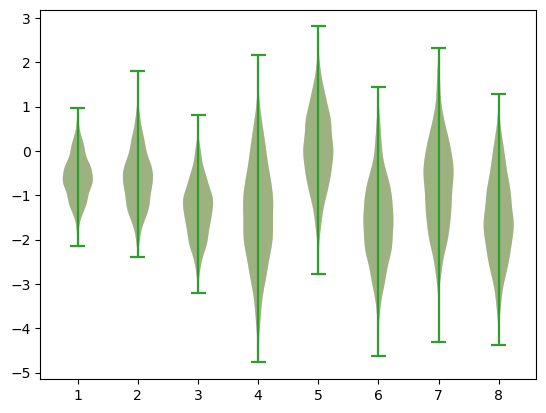

In [13]:
plt.violinplot(np.array([psamp[f'gw_clm({i})'] for i in range((lmx+1)**2-1)]).T)
plt.violinplot(samples['params'][f'gw_clm({(lmx+1)**2-1})'])
plt.violinplot(np.array([np2pddf[f'gw_clm({i})'] for i in range((lmx+1)**2-1)]).T)

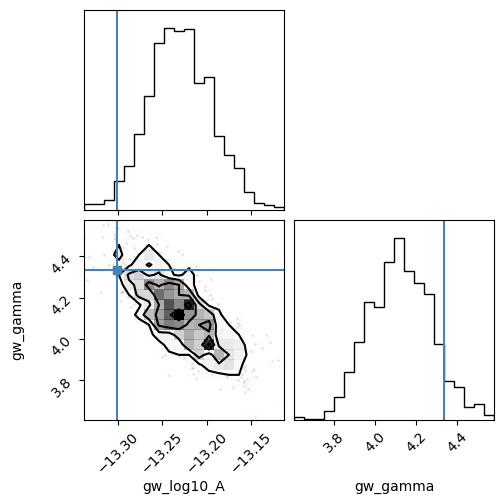

In [14]:
corner(np.array([samples['gw_log10_A'], samples['gw_gamma']]).T,
       labels=['gw_log10_A', 'gw_gamma'],
       truths=[injparams['gw_log10_A'], injparams['gw_gamma']]);

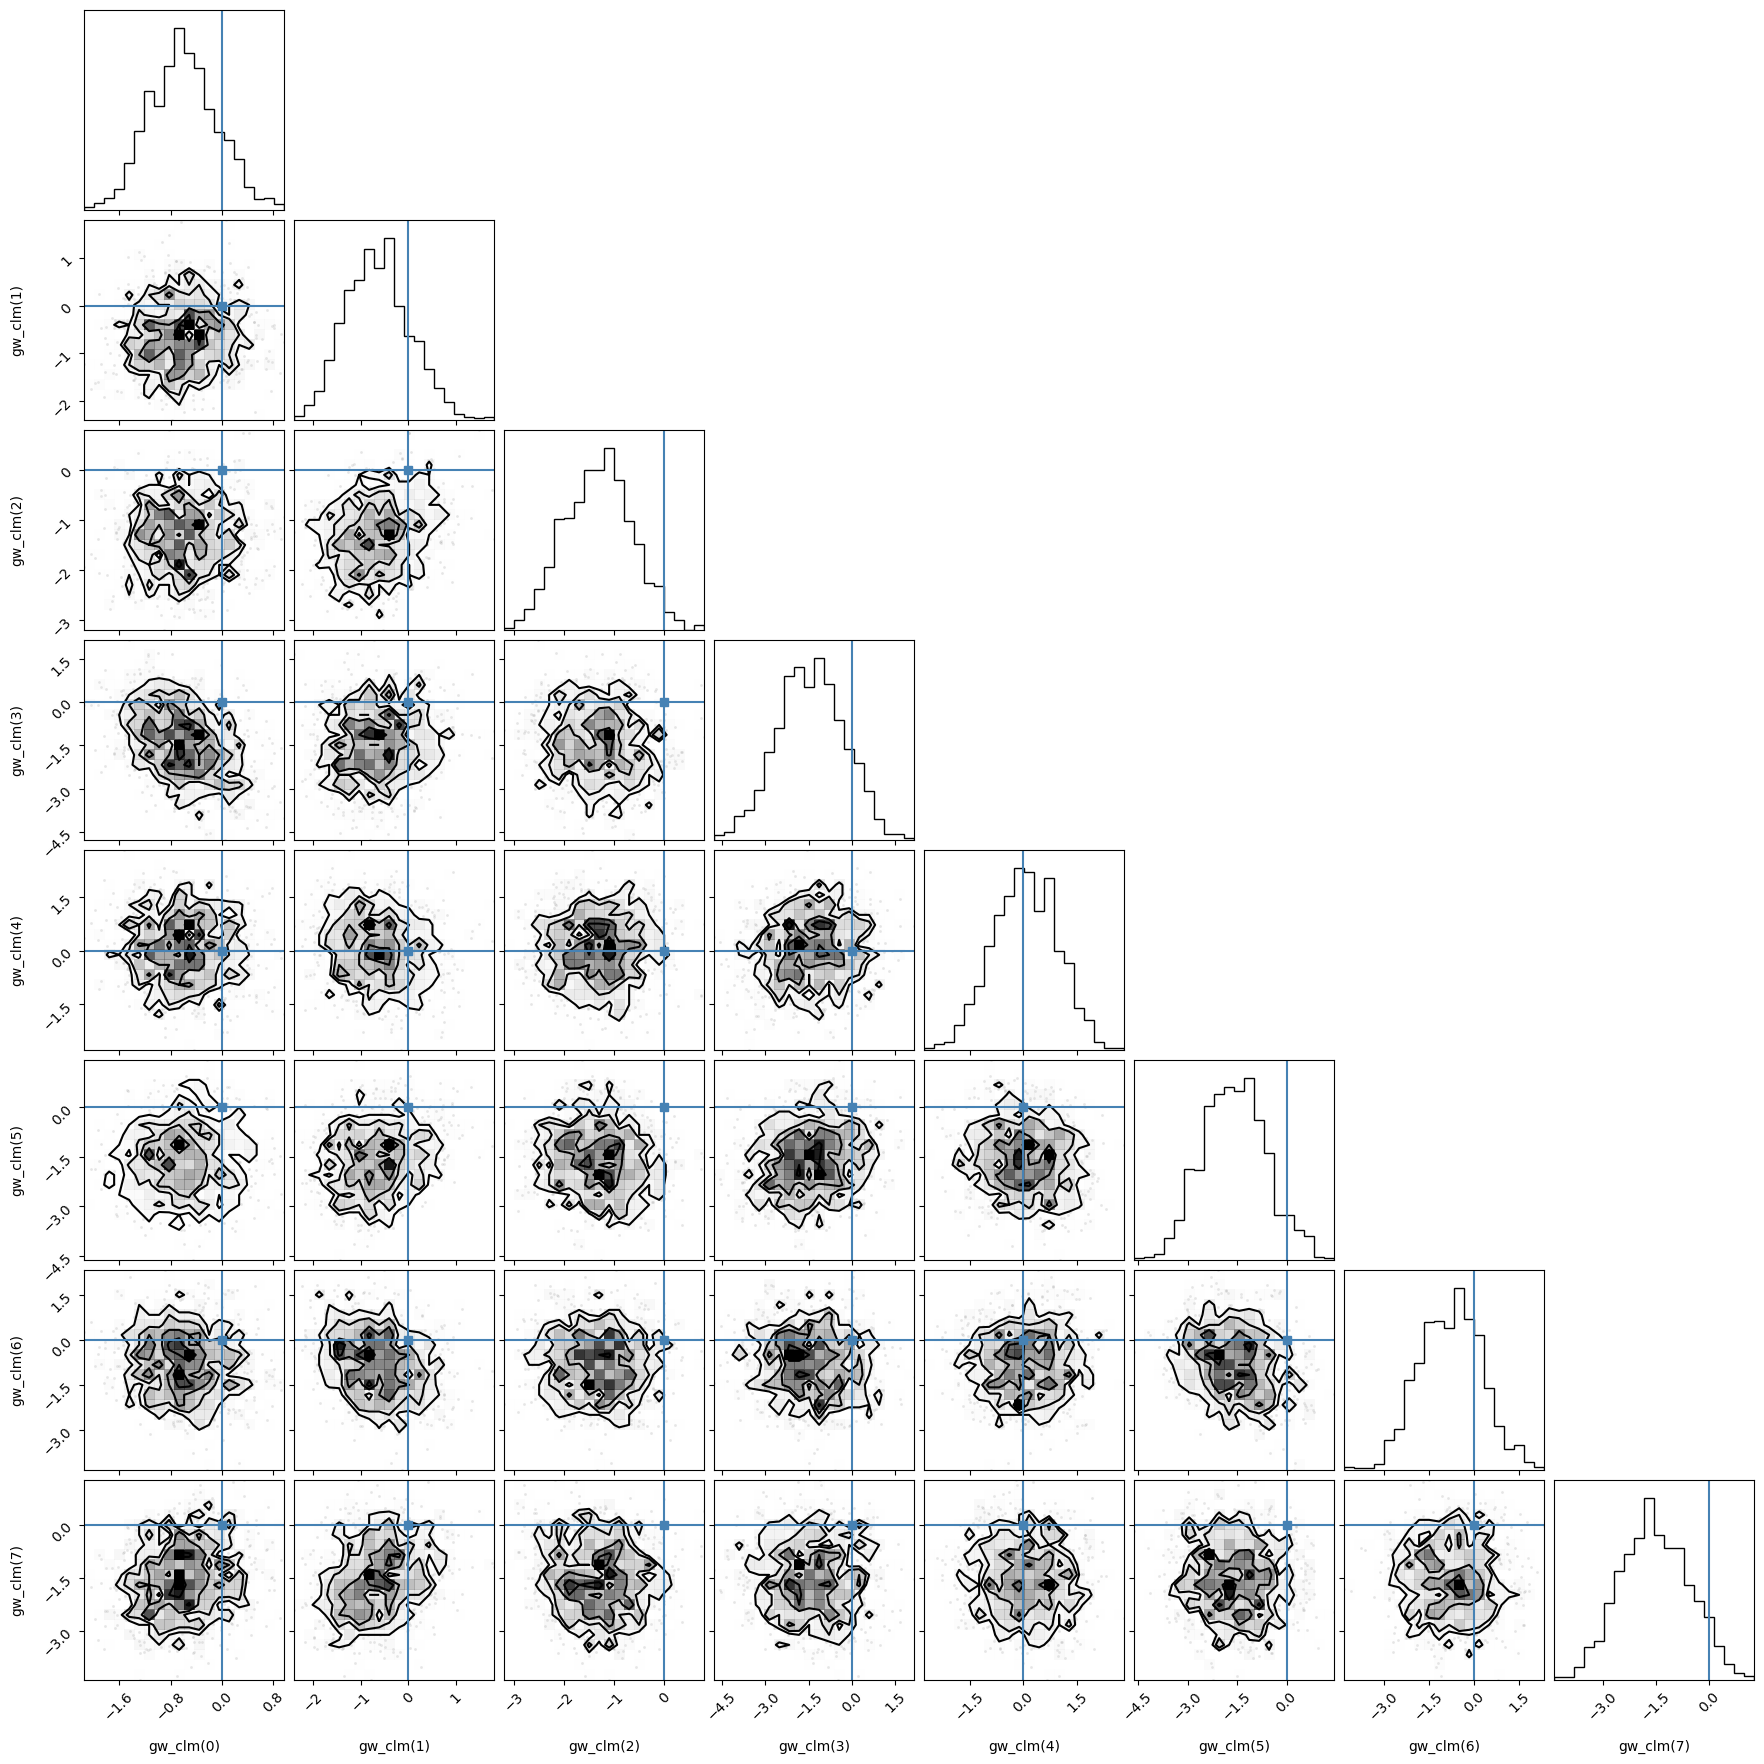

In [15]:
corner(np.array([samples['gw_clm(8)'][:, i] for i in range(8)]).T,
       labels=[f'gw_clm({i})' for i in range(8)],
       truths=np.zeros(8));

In [16]:
holdangpow = np.zeros((1000, lmx))
for i in range(1000):
    holdangpow[i,:] = dac.clm2angpowspec(samples['gw_clm(8)'][i], lmax=lmx)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x780b283d9640>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x780b2845dd60>,
 'cmins': <matplotlib.collections.LineCollection at 0x780b28213da0>,
 'cbars': <matplotlib.collections.LineCollection at 0x780b28213ef0>}

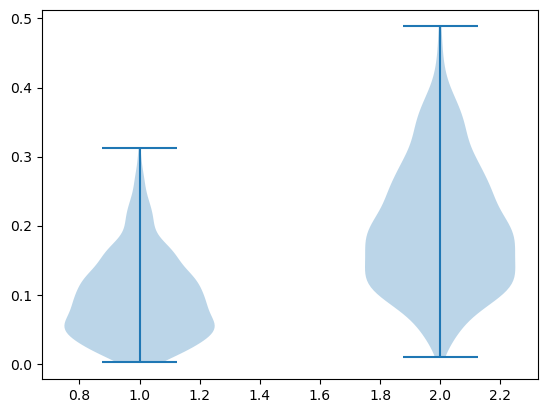

In [17]:
plt.violinplot(holdangpow/(4*np.pi), positions=np.arange(1, lmx+1))

## narrowband analysis

In [5]:
psrs = mdcpsrs
T = ds.getspan(psrs)
psr_pos = jnp.array([psr.pos for psr in psrs])
comps = 6 # freq components
lmx = 6
nsi=16

lsphorfs = []
nclms = []
for lm in range(comps):
    lsphorfs.append(functools.partial(dac.get_linspharm_orf(psr_pos, lmax=lmx, nside=nsi), c00=jnp.sqrt(4*jnp.pi)))
    nclms.append((lmx+1)**2-1)


ds.prior.priordict_standard['(.*_)?rednoise_log10_A.*'] = [-20, -19]
ds.prior.priordict_standard['(.*_)?rednoise_gamma.*'] = [0, 1]
ds.prior.priordict_standard['(.*_)?log10_t2equad.*'] = [-15, -14]
ds.prior.priordict_standard['(.*_)?efac.*'] = [1.0, 1.001]
#ds.prior.priordict_standard.update({f'gw_clm\\(([0-9]*)\\)': [-5, 5]})
ds.prior.priordict_standard.update({f'gw_clm_f[0-9]+\\(([0-9]*)\\)': [-5, 5]})

print(ds.prior.priordict_standard)



psrpos = np.array([p.pos for p in psrs])

pxorf = dac.get_pixel_orf(psrpos, nside=nsi)

glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.freespectrum],
                                    [lsphorfs],
                                    components=comps, T=T, name='gw', nbasis=[nclms])


# m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True)]) for psr in psrs],
#                        commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
#                        globalgp = glgp_mdc)

m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makenoise_measurement_simple(psr),
                                             ds.makegp_timing(psr, svd=True),
                                             ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
                                             globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

{'(.*_)?efac': [0.9, 1.1], '(.*_)?t2equad': [-8.5, -5], '(.*_)?tnequad': [-8.5, -5], '(.*_)?log10_ecorr': [-8.5, -5], '(.*_)?rednoise_log10_A.*': [-20, -19], '(.*_)?rednoise_gamma.*': [0, 1], '(.*_)?rednoise_log10_fb': [-9, -6], '(.*_)?red_noise_log10_A.*': [-20, -11], '(.*_)?red_noise_gamma.*': [0, 7], '(.*_)?red_noise_log10_fb': [-9, -6], 'crn_log10_A.*': [-18, -11], 'crn_gamma.*': [0, 7], 'crn_log10_fb': [-9, -6], 'gw_(.*_)?log10_A': [-18, -11], 'gw_(.*_)?gamma': [0, 7], 'gw_log10_fb': [-9, -6], '(.*_)?dmgp_log10_A': [-20, -11], '(.*_)?dmgp_gamma': [0, 7], '(.*_)?dmgp_alpha': [1, 3], 'crn_log10_rho': [-9, -4], 'gw_(.*_)?log10_rho': [-9, -4], '(.*_)?red_noise_log10_rho\\(([0-9]*)\\)': [-9, -4], '(.*_)?red_noise_crn_log10_rho\\(([0-9]*)\\)': [-9, -4], 'cw_ra': [0, 6.283185307179586], 'cw_dec': [-1.5707963267948966, 1.5707963267948966], 'cw_inc': [0, 3.141592653589793], 'cw_sindec': [-1.0, 1.0], 'cw_cosinc': [-1.0, 1.0], 'cw_psi': [0, 3.141592653589793], 'cw_log10_f0': [-9.0, -7.0], 'c

In [6]:
mdc_jlogl.params

['J0030+0451_efac',
 'J0030+0451_log10_t2equad',
 'J0030+0451_rednoise_gamma',
 'J0030+0451_rednoise_log10_A',
 'J0218+4232_efac',
 'J0218+4232_log10_t2equad',
 'J0218+4232_rednoise_gamma',
 'J0218+4232_rednoise_log10_A',
 'J0437-4715_efac',
 'J0437-4715_log10_t2equad',
 'J0437-4715_rednoise_gamma',
 'J0437-4715_rednoise_log10_A',
 'J0613-0200_efac',
 'J0613-0200_log10_t2equad',
 'J0613-0200_rednoise_gamma',
 'J0613-0200_rednoise_log10_A',
 'J0621+1002_efac',
 'J0621+1002_log10_t2equad',
 'J0621+1002_rednoise_gamma',
 'J0621+1002_rednoise_log10_A',
 'J0711-6830_efac',
 'J0711-6830_log10_t2equad',
 'J0711-6830_rednoise_gamma',
 'J0711-6830_rednoise_log10_A',
 'J0751+1807_efac',
 'J0751+1807_log10_t2equad',
 'J0751+1807_rednoise_gamma',
 'J0751+1807_rednoise_log10_A',
 'J0900-3144_efac',
 'J0900-3144_log10_t2equad',
 'J0900-3144_rednoise_gamma',
 'J0900-3144_rednoise_log10_A',
 'J1012+5307_efac',
 'J1012+5307_log10_t2equad',
 'J1012+5307_rednoise_gamma',
 'J1012+5307_rednoise_log10_A',
 

In [24]:

initpars = {f'{p.name}_rednoise_gamma':2.0 for p in psrs}
initpars.update({f'{p.name}_rednoise_log10_A':-15.0 for p in psrs})
for p in psrs:
    initpars[f'{p.name}_log10_t2equad'] = -15.0
    initpars[f'{p.name}_efac'] = 1.0
# initpars['gw_log10_A'] = -15.0
# initpars['gw_gamma'] = 4.33
initpars.update({'gw_log10_rho(6)': np.full((6), -7.0)})
initpars.update({'gw_log10_rho(2)': np.full((2), -7.0)})
initpars.update({f'gw_log10_rho({comps})': np.full((comps), -7.0)})


for f in range(comps):
    initpars[f'gw_clm_f{f}({nclms[f]})'] = np.zeros(nclms[f])

print(m_mdc.logL(initpars))

print(mdc_jlogl(initpars))

aligned_init = {p: initpars[p] for p in mdc_jlogl.params if p in initpars}
print("Aligned init params:", aligned_init)

38471.55230340807
38471.55230340807
Aligned init params: {'J0030+0451_efac': 1.0, 'J0030+0451_log10_t2equad': -15.0, 'J0030+0451_rednoise_gamma': 2.0, 'J0030+0451_rednoise_log10_A': -15.0, 'J0218+4232_efac': 1.0, 'J0218+4232_log10_t2equad': -15.0, 'J0218+4232_rednoise_gamma': 2.0, 'J0218+4232_rednoise_log10_A': -15.0, 'J0437-4715_efac': 1.0, 'J0437-4715_log10_t2equad': -15.0, 'J0437-4715_rednoise_gamma': 2.0, 'J0437-4715_rednoise_log10_A': -15.0, 'J0613-0200_efac': 1.0, 'J0613-0200_log10_t2equad': -15.0, 'J0613-0200_rednoise_gamma': 2.0, 'J0613-0200_rednoise_log10_A': -15.0, 'J0621+1002_efac': 1.0, 'J0621+1002_log10_t2equad': -15.0, 'J0621+1002_rednoise_gamma': 2.0, 'J0621+1002_rednoise_log10_A': -15.0, 'J0711-6830_efac': 1.0, 'J0711-6830_log10_t2equad': -15.0, 'J0711-6830_rednoise_gamma': 2.0, 'J0711-6830_rednoise_log10_A': -15.0, 'J0751+1807_efac': 1.0, 'J0751+1807_log10_t2equad': -15.0, 'J0751+1807_rednoise_gamma': 2.0, 'J0751+1807_rednoise_log10_A': -15.0, 'J0900-3144_efac': 1.0, '

In [30]:
def model():
    gammas = numpyro.sample("gammas", dist.Uniform(0, 1).expand([len(psrs)]))
    log10_As = numpyro.sample("log10_As", dist.Uniform(-21, -20).expand([len(psrs)]))
    efacs = numpyro.sample("efacs", dist.Uniform(1, 1.01).expand([len(psrs)]))
    equads = numpyro.sample("equads", dist.Uniform(-15, -14).expand([len(psrs)]))
    fnclm = []
    for fi in range(comps):
        fnclm.append(numpyro.sample(f"gw_clm_f{fi}({nclms[fi]})", dist.Uniform(-5, 5).expand([nclms[fi]])))
    gwl10r = numpyro.sample(f'gw_log10_rho({comps})', dist.Uniform(-9, -4).expand([comps]))

    paramdict = {}
    paramdict = {f'{psr.name}_rednoise_gamma': gammas[ii] for ii, psr in enumerate(psrs)}
    paramdict.update({f'{psr.name}_rednoise_log10_A': log10_As[ii] for ii, psr in enumerate(psrs)})
    paramdict.update({f'{psr.name}_efac': efacs[ii] for ii, psr in enumerate(psrs)})
    paramdict.update({f'{psr.name}_log10_t2equad': equads[ii] for ii, psr in enumerate(psrs)})
    for fi in range(comps):
        paramdict[f'gw_clm_f{fi}({nclms[fi]})'] = fnclm[fi]
    paramdict[f'gw_log10_rho({comps})'] = gwl10r
    # params['crn_gamma'] = gwgam
    # params['crn_log10_A'] = gwl10A
    numpyro.deterministic('params', paramdict)
    numpyro.factor('logl', mdc_jlogl(paramdict))

In [31]:
# def model():
#     gammas = []
#     l10As = []
#     efacs = []
#     equads = []

#     for p in psrs:
#         gammas.append(numpyro.sample(f'{p.name}_rednoise_gamma', dist.Uniform(0, 1)))
#         l10As.append(numpyro.sample(f'{p.name}_rednoise_log10_A', dist.Uniform(-21, -20)))
#         efacs.append(numpyro.sample(f'{p.name}_efac', dist.Uniform(1, 1.01)))
#         equads.append(numpyro.sample(f'{p.name}_log10_t2equad', dist.Uniform(-15, -14)))
#     # gammas = numpyro.sample("gammas", dist.Uniform(0, 1).expand([len(psrs)]))
#     # log10_As = numpyro.sample("log10_As", dist.Uniform(-21, -20).expand([len(psrs)]))
#     # efacs = numpyro.sample("efacs", dist.Uniform(1, 1.01).expand([len(psrs)]))
#     # equads = numpyro.sample("equads", dist.Uniform(-15, -14).expand([len(psrs)]))
#     fnclm = []
#     for fi in range(comps):
#         fnclm.append(numpyro.sample(f"gw_clm_f{fi}({nclms[fi]})", dist.Uniform(-5, 5).expand([nclms[fi]])))
#     gwl10r = numpyro.sample(f'gw_log10_rho({comps})', dist.Uniform(-9, -4).expand([comps]))

#     paramdict = {}
#     paramdict.update({f'{psr.name}_rednoise_gamma': gammas[ii] for ii, psr in enumerate(psrs)}) 
#     paramdict.update({f'{psr.name}_rednoise_log10_A': l10As[ii] for ii, psr in enumerate(psrs)})
#     paramdict.update({f'{psr.name}_efac': efacs[ii] for ii, psr in enumerate(psrs)})
#     paramdict.update({f'{psr.name}_log10_t2equad': equads[ii] for ii, psr in enumerate(psrs)})
#     for fi in range(comps):
#         paramdict[f'gw_clm_f{fi}({nclms[fi]})'] = fnclm[fi]
#     paramdict[f'gw_log10_rho({comps})'] = gwl10r
#     print(paramdict)
#     # params['crn_gamma'] = gwgam
#     # params['crn_log10_A'] = gwl10A
#     numpyro.deterministic('params', paramdict)
#     numpyro.factor('logl', mdc_jlogl(paramdict))

In [32]:
mykernel = infer.NUTS(model, max_tree_depth=5, 
                      init_strategy=numpyro.infer.initialization.init_to_value(values=aligned_init))
mcmc = infer.MCMC(mykernel, num_warmup=50, num_samples=50)

In [33]:
mcmc.run(jax.random.key(100))

sample: 100%|██████████| 100/100 [01:21<00:00,  1.22it/s, 3 steps of size 3.86e-02. acc. prob=0.67]


In [34]:
mcmc.print_summary()


                        mean       std    median      5.0%     95.0%     n_eff     r_hat
          efacs[0]      1.01      0.00      1.01      1.01      1.01      4.10      1.56
          efacs[1]      1.00      0.00      1.00      1.00      1.00      5.21      1.64
          efacs[2]      1.01      0.00      1.01      1.01      1.01      2.82      3.18
          efacs[3]      1.01      0.00      1.01      1.01      1.01      5.74      1.32
          efacs[4]      1.00      0.00      1.00      1.00      1.00      7.85      0.98
          efacs[5]      1.00      0.00      1.00      1.00      1.00      7.92      1.05
          efacs[6]      1.01      0.00      1.01      1.00      1.01      3.94      1.57
          efacs[7]      1.01      0.00      1.01      1.01      1.01      3.16      2.14
          efacs[8]      1.01      0.00      1.01      1.01      1.01      4.70      1.23
          efacs[9]      1.00      0.00      1.00      1.00      1.00      6.29      1.20
         efacs[10]  

In [12]:
nclms

[48, 48, 48, 48, 48, 48]

In [35]:
samples = mcmc.get_samples()
spcpars = [f'gw_clm_f{fi}({nclms[fi]})' for fi in range(comps)]
spcpars.append(f'gw_log10_rho({comps})')

In [36]:
samples

{'efacs': Array([[1.00969553, 1.00144937, 1.00844352, ..., 1.00618831, 1.00422391,
         1.00773648],
        [1.00969341, 1.00142972, 1.00843642, ..., 1.0062059 , 1.00422615,
         1.00772856],
        [1.00969106, 1.00144368, 1.00843085, ..., 1.00620021, 1.0042529 ,
         1.00774445],
        ...,
        [1.009755  , 1.00122594, 1.00863024, ..., 1.00605746, 1.0040348 ,
         1.0075352 ],
        [1.00975076, 1.00121303, 1.00862819, ..., 1.00602313, 1.00404447,
         1.00753514],
        [1.00974816, 1.00122089, 1.00862852, ..., 1.00601053, 1.00404859,
         1.00753201]], dtype=float64),
 'equads': Array([[-14.37628156, -14.56473329, -14.61934454, ..., -14.44671851,
         -14.8362132 , -14.29776547],
        [-14.37696056, -14.56371875, -14.62092719, ..., -14.44622598,
         -14.83619783, -14.29591484],
        [-14.37494776, -14.56336058, -14.61993908, ..., -14.44499697,
         -14.83646388, -14.29785945],
        ...,
        [-14.34349768, -14.53343737, -

In [37]:
samples.keys()

dict_keys(['efacs', 'equads', 'gammas', 'gw_clm_f0(48)', 'gw_clm_f1(48)', 'gw_clm_f2(48)', 'gw_clm_f3(48)', 'gw_clm_f4(48)', 'gw_clm_f5(48)', 'gw_log10_rho(6)', 'log10_As', 'params'])

In [38]:
chdf = pd.DataFrame.from_dict(mcmc.get_samples(), orient='index')

AttributeError: 'dict' object has no attribute 'dtype'

In [39]:
sdf = dac.npyrosamples2pddf(mcmc.get_samples(), special_pars=spcpars)

/home/levis/play_disco/discovery/src/discovery/anis_coefficients.py:708: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pdsamp[f'{trimparname}({i})'] = samples['params'][sp][:, i]
/home/levis/play_disco/discovery/src/discovery/anis_coefficients.py:708: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pdsamp[f'{trimparname}({i})'] = samples['params'][sp][:, i]
/home/levis/play_disco/discovery/src/discovery/anis_coefficients.py:708: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

In [40]:
sdf.shape

(50, 438)

In [42]:
4*36+48*6+6

438

In [41]:
sdf.columns

Index(['J0030+0451_efac', 'J0030+0451_log10_t2equad',
       'J0030+0451_rednoise_gamma', 'J0030+0451_rednoise_log10_A',
       'J0218+4232_efac', 'J0218+4232_log10_t2equad',
       'J0218+4232_rednoise_gamma', 'J0218+4232_rednoise_log10_A',
       'J0437-4715_efac', 'J0437-4715_log10_t2equad',
       ...
       'gw_clm_f5(44)', 'gw_clm_f5(45)', 'gw_clm_f5(46)', 'gw_clm_f5(47)',
       'gw_log10_rho(0)', 'gw_log10_rho(1)', 'gw_log10_rho(2)',
       'gw_log10_rho(3)', 'gw_log10_rho(4)', 'gw_log10_rho(5)'],
      dtype='str', length=438)

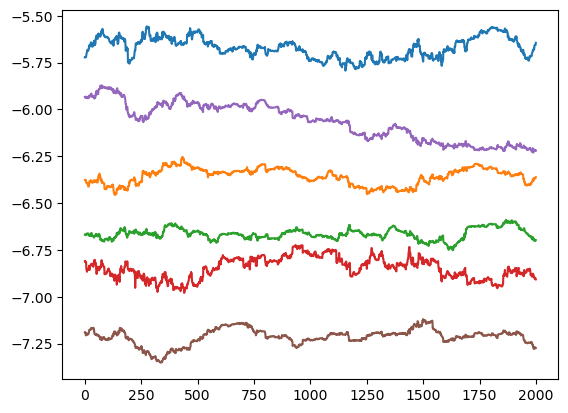

In [110]:
plt.plot(samples['gw_log10_rho(6)'])

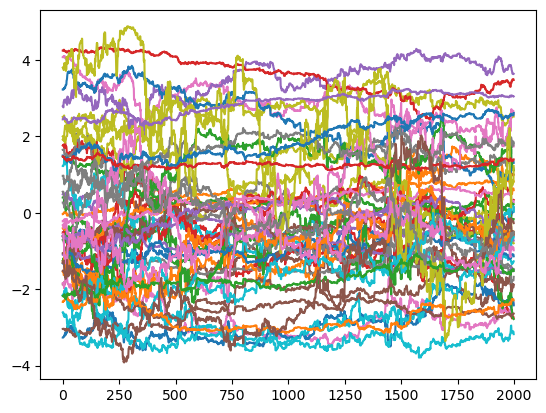

In [112]:
plt.plot(samples['gw_clm_f0(48)'])

In [105]:
holdangpow = np.zeros((1000, lmx, comps))
for i in range(1000):
    for fi in range(comps):
        holdangpow[i,:,fi] = dac.clm2angpowspec(samples[f'gw_clm_f{fi}({nclms[fi]})'][i], lmax=lmx)

[{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7d716ce049e0>,
  'cmaxes': <matplotlib.collections.LineCollection at 0x7d716cffccb0>,
  'cmins': <matplotlib.collections.LineCollection at 0x7d716d1e2e70>,
  'cbars': <matplotlib.collections.LineCollection at 0x7d716ce04350>},
 {'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7d7163f7c350>,
  'cmaxes': <matplotlib.collections.LineCollection at 0x7d716cc4be90>,
  'cmins': <matplotlib.collections.LineCollection at 0x7d7163ef8c50>,
  'cbars': <matplotlib.collections.LineCollection at 0x7d716cc492e0>},
 {'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7d716cc49af0>,
  'cmaxes': <matplotlib.collections.LineCollection at 0x7d7163ef9dc0>,
  'cmins': <matplotlib.collections.LineCollection at 0x7d7163efb1d0>,
  'cbars': <matplotlib.collections.LineCollection at 0x7d716cc49850>},
 {'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7d7163ef97f0>,
  'cmaxes': <matplotlib.collecti

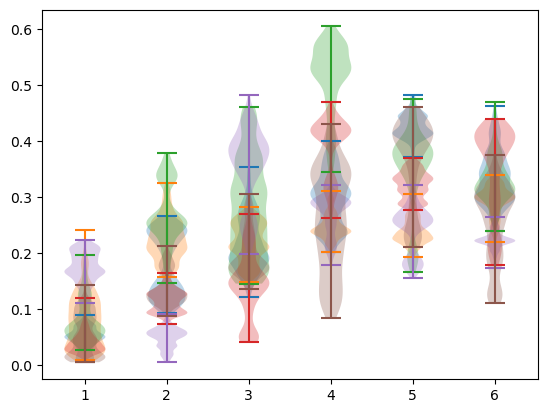

In [109]:
[plt.violinplot(holdangpow[:, :, fi] /(4*np.pi), positions=np.arange(1, lmx+1)) for fi in range(comps)]

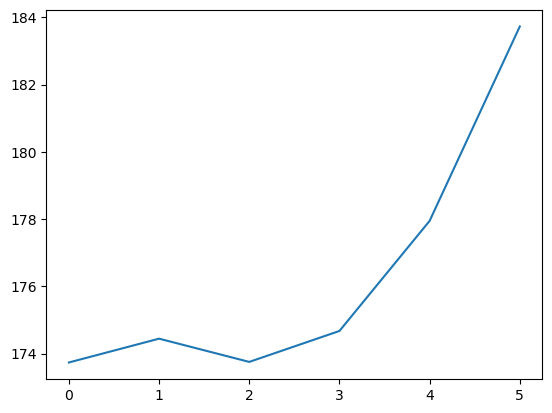

In [100]:
plt.plot(dac.clm2angpowspec(samples['gw_clm_f0(48)'], lmx))

In [48]:
npmodel = ds_numpyro.makemodel(m_mdc.logL)
npsampler = ds_numpyro.makesampler_nuts(npmodel, num_warmup=10, num_samples=4000,
                                        init_strategy=numpyro.infer.initialization.init_to_value(values=aligned_init))



In [49]:
#npsampler.warmup(jax.random.key(0))

print('Starting sampler')
# print(initpars)
# npsampler.warmup(jax.random.key(0), init_params=initpars)
# print('Warmup done')

npsampler.run(jax.random.key(0))
chain = npsampler.to_df()

Starting sampler
params={'J0030+0451_efac': Array(1.06614156, dtype=float64), 'J0030+0451_log10_t2equad': Array(-6.97751878, dtype=float64), 'J0030+0451_rednoise_gamma': Array(0.15470673, dtype=float64), 'J0030+0451_rednoise_log10_A': Array(-19.36866675, dtype=float64), 'J0218+4232_efac': Array(0.92932488, dtype=float64), 'J0218+4232_log10_t2equad': Array(-6.14306041, dtype=float64), 'J0218+4232_rednoise_gamma': Array(0.13160245, dtype=float64), 'J0218+4232_rednoise_log10_A': Array(-19.85669129, dtype=float64), 'J0437-4715_efac': Array(0.95619146, dtype=float64), 'J0437-4715_log10_t2equad': Array(-7.93113227, dtype=float64), 'J0437-4715_rednoise_gamma': Array(0.14261415, dtype=float64), 'J0437-4715_rednoise_log10_A': Array(-19.85821605, dtype=float64), 'gw_clm_f0(48)': Array(-0.29017537, dtype=float64), 'gw_clm_f1(48)': Array(-3.4235468, dtype=float64), 'gw_clm_f2(48)': Array(-3.20860295, dtype=float64), 'gw_log10_rho(3)': Array(-7.09265489, dtype=float64)}
argmap=['gw_log10_rho(3)']
p

TypeError: mul got incompatible shapes for broadcasting: (2, 1, 1), (6, 3, 3).

In [8]:
mdcpars = {f'{p.name}_rednoise_gamma':2.0 for p in psrs}
mdcpars.update({f'{p.name}_rednoise_log10_A':-14.0 for p in psrs})
mdcpars.update({f'{p.name}_log10_t2equad':-14.0 for p in psrs})
mdcpars.update({f'{p.name}_efac':1.0 for p in psrs})
mdcpars['gw_log10_rho(6)'] = np.array([-5 for adx in range(comps)])
mdcpars.update({f'gw_clm_f{adx}({(lmx+1)**2-1})':np.zeros((lmx+1)**2-1) for adx in range(comps)})
#mdcpars[f'gw_clm({(lmx+1)**2-1})'] = badclms

m_mdc.logL(mdcpars)

Array(43949.94721959, dtype=float64)

In [70]:
# LSS mdc has no red noise, efac=1, no equad so set to -16
psrs = mdcpsrs

def model():
    gammas = numpyro.sample("gammas", dist.Uniform(0, 1).expand([len(psrs)]))
    log10_As = numpyro.sample("log10_As", dist.Uniform(-20, -19).expand([len(psrs)]))
    clmdraws = [numpyro.sample(f"gw_clm_f{adx}({(lmx+1)**2-1})", dist.Uniform(-2.5, 2.5).expand([(lmx+1)**2-1])) for adx in range(comps)]
    gwrhos = numpyro.sample('gw_log10_rho(6)', dist.Uniform(-9, -4).expand([comps]))

    params = {f'{psr.name}_rednoise_gamma': gammas[ii] for ii, psr in enumerate(psrs)}
    params.update({f'{psr.name}_rednoise_log10_A': log10_As[ii] for ii, psr in enumerate(psrs)})
    params.update({f'{p.name}_log10_t2equad':-16.0 for p in psrs})
    params.update({f'{p.name}_efac':1.0 for p in psrs})
    params.update({f"gw_clm_f{adx}({(lmx+1)**2-1})": clmdraws[adx] for adx in range(comps)})
    params['gw_log10_rho(6)'] = gwrhos
    numpyro.deterministic('params', params)
    numpyro.factor('logl', mdc_jlogl(params))


mykernel = infer.NUTS(model, max_tree_depth=5)
mcmc = infer.MCMC(mykernel, num_warmup=1000, num_samples=2000)


In [71]:
mcmc.run(jax.random.key(100))

sample: 100%|██████████| 3000/3000 [14:29<00:00,  3.45it/s, 7 steps of size 1.42e-01. acc. prob=0.75]   


In [72]:
samples = mcmc.get_samples()
mcmc.print_summary()


                        mean       std    median      5.0%     95.0%     n_eff     r_hat
         gammas[0]      0.48      0.29      0.46      0.03      0.90    368.65      1.00
         gammas[1]      0.49      0.29      0.49      0.06      0.93    282.02      1.01
         gammas[2]      0.50      0.29      0.51      0.00      0.89    331.48      1.00
         gammas[3]      0.51      0.27      0.51      0.13      0.99    356.58      1.00
         gammas[4]      0.48      0.29      0.47      0.04      0.93    303.41      1.00
         gammas[5]      0.50      0.29      0.50      0.06      0.95    294.92      1.01
         gammas[6]      0.53      0.29      0.56      0.07      0.97    344.19      1.00
         gammas[7]      0.49      0.28      0.48      0.01      0.90    292.32      1.00
         gammas[8]      0.51      0.29      0.51      0.12      1.00    273.39      1.00
         gammas[9]      0.51      0.28      0.51      0.09      0.96    368.00      1.02
        gammas[10]  

In [89]:
specpars = [f'gw_clm_f{adx}({(lmx+1)**2-1})' for adx in range(comps)]
specpars.append('gw_log10_rho(6)')
narrow_np2pddf = dac.npyrosamples2pddf(samples, special_pars=specpars)

In [90]:
holdangpow = np.zeros((1000, lmx, comps))
for i in range(1000):
    for c in range(comps):
        holdangpow[i,:, c] = dac.clm2angpowspec(samples['params'][f'gw_clm_f{c}({(lmx+1)**2-1})'][i], lmax=lmx)

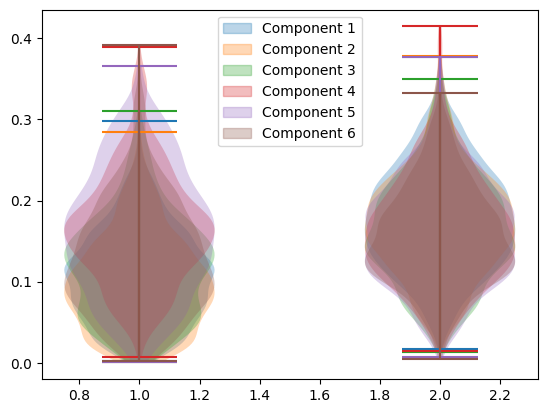

In [91]:
labels = []
def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))


for c in range(comps):
    add_label(plt.violinplot(holdangpow[:,:, c]/(4*np.pi), positions=np.arange(1, lmx+1)), f'Component {c+1}')

plt.legend(*zip(*labels), loc='upper center')

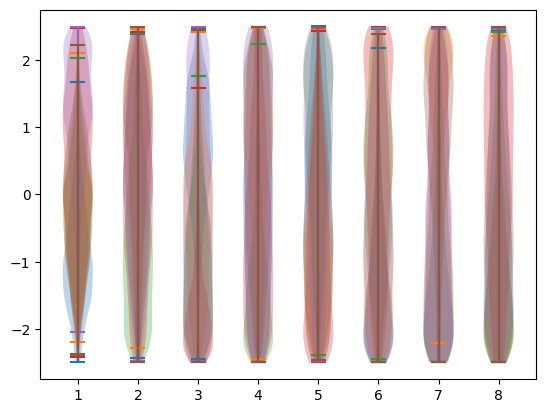

In [92]:
for c in range(comps):
    add_label(plt.violinplot(np.array([narrow_np2pddf[f'gw_clm_f{c}({i})'] for i in range((lmx+1)**2-1)]).T), f'Component {c+1}')